# distances — pairwise distance heatmap

Visualises an N×N distance matrix as a colour-coded grid of rounded-rectangle cells.

```
distances(data, *, columns, metric, color_ramp,
          width, height, padding, interactive) -> np.ndarray | None
```

Input can be:
- **Pre-computed N×N matrix** — passed through directly
- **(N, D) embedding array** — `cdist(metric)` computed internally
- **DataFrame + `columns`** — feature columns extracted then `cdist` computed

Limit: N ≤ 2 236 (budget of 5 M instances). Requires `scipy`.

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Pre-computed distance matrix

Distance matrix shape: (40, 40)
distances: 40×40 (1,600 cells), 700×700, render 217.0ms


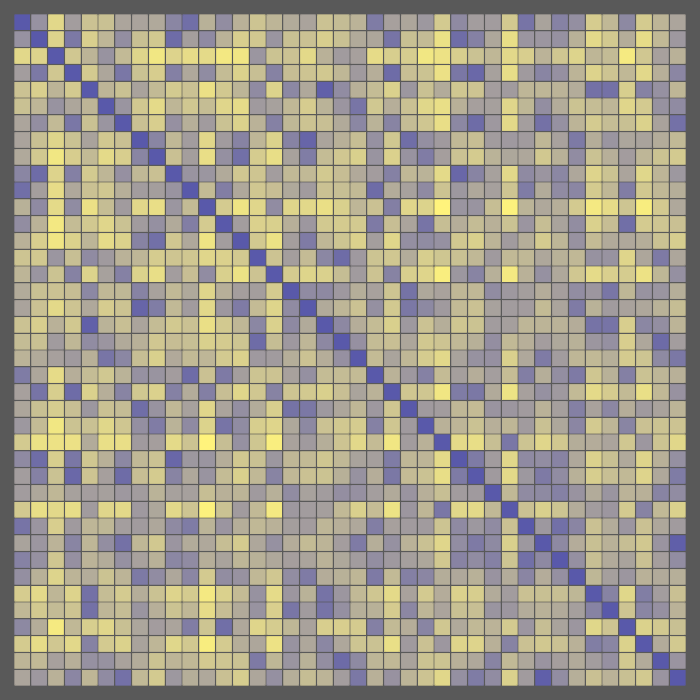

In [2]:
from scipy.spatial.distance import cdist

rng = np.random.default_rng(42)
pts = rng.uniform(0, 10, (40, 2)).astype(np.float32)
D   = cdist(pts, pts, metric="euclidean").astype(np.float32)

print(f"Distance matrix shape: {D.shape}")
img = jv.distances(D, width=700, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 2 — From (N, D) embeddings — euclidean, cosine, manhattan

metric=euclidean
distances: 100×100 (10,000 cells), 700×700, render 5.7ms


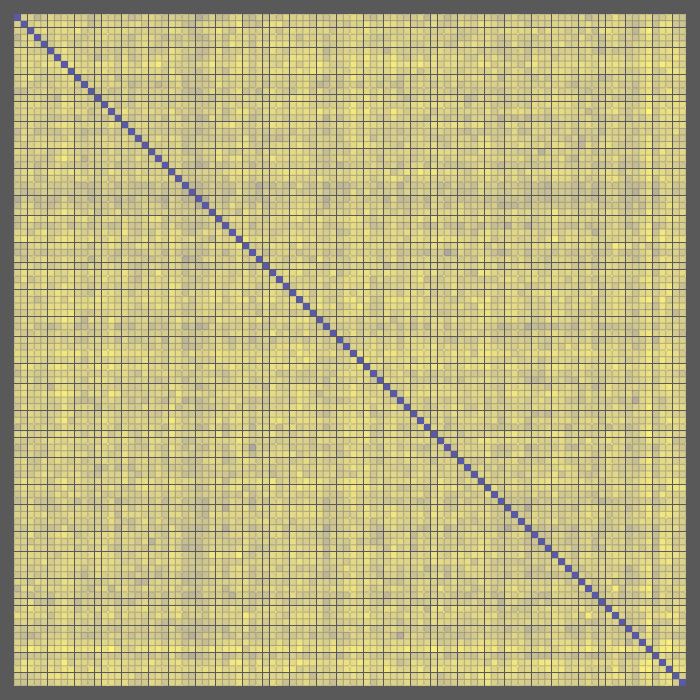

metric=cosine
distances: 100×100 (10,000 cells), 700×700, render 4.8ms


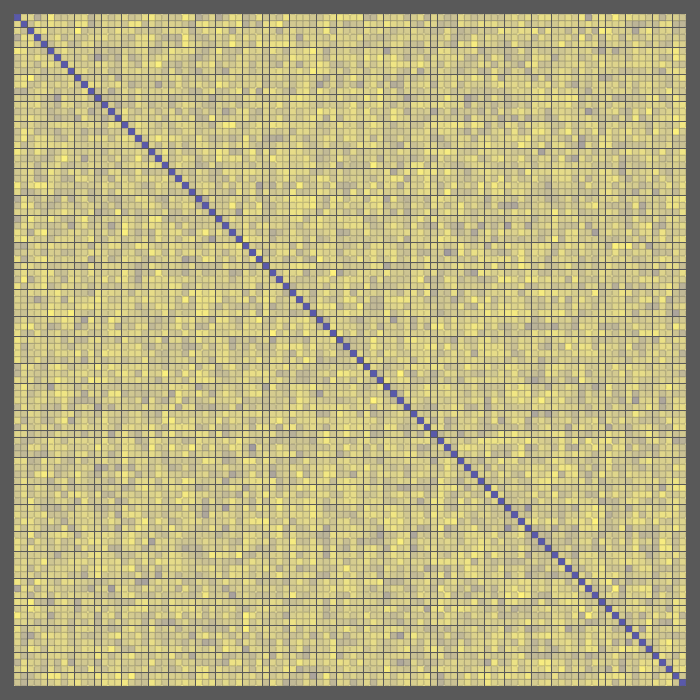

metric=manhattan


ValueError: Unknown Distance Metric: manhattan

In [3]:
rng = np.random.default_rng(0)
embeddings = rng.standard_normal((100, 32)).astype(np.float32)  # 100 items, 32-dim

for metric in ["euclidean", "cosine", "manhattan"]:
    print(f"metric={metric}")
    img = jv.distances(embeddings, metric=metric, width=700, height=700)
    display(Image.fromarray(img, mode='RGBA'))

## 3 — Custom color ramp

distances: 80×80 (6,400 cells), 700×700, render 4.3ms


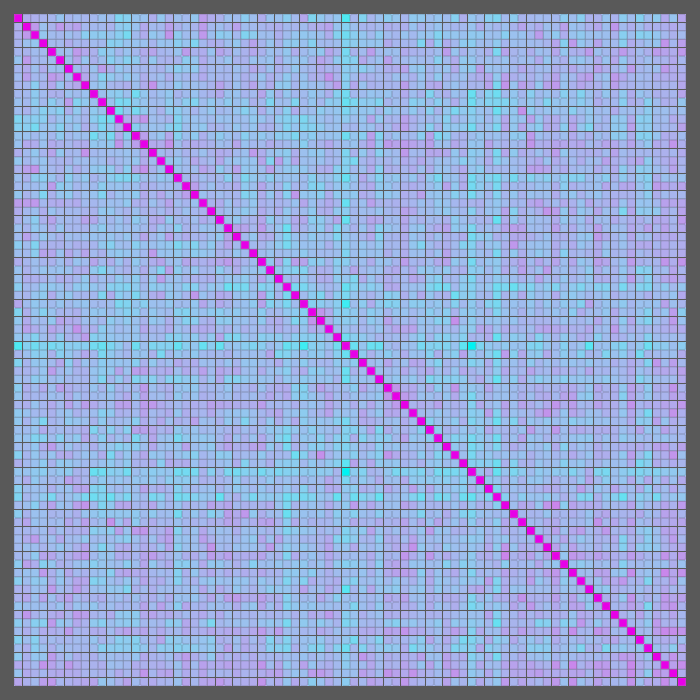

In [4]:
rng = np.random.default_rng(5)
emb = rng.standard_normal((80, 16)).astype(np.float32)

# Magenta → cyan
img = jv.distances(emb,
                   color_ramp=((0.8, 0.0, 0.8), (0.0, 0.9, 0.9)),
                   width=700, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 4 — From a pandas DataFrame

distances: 60×60 (3,600 cells), 700×700, render 3.5ms


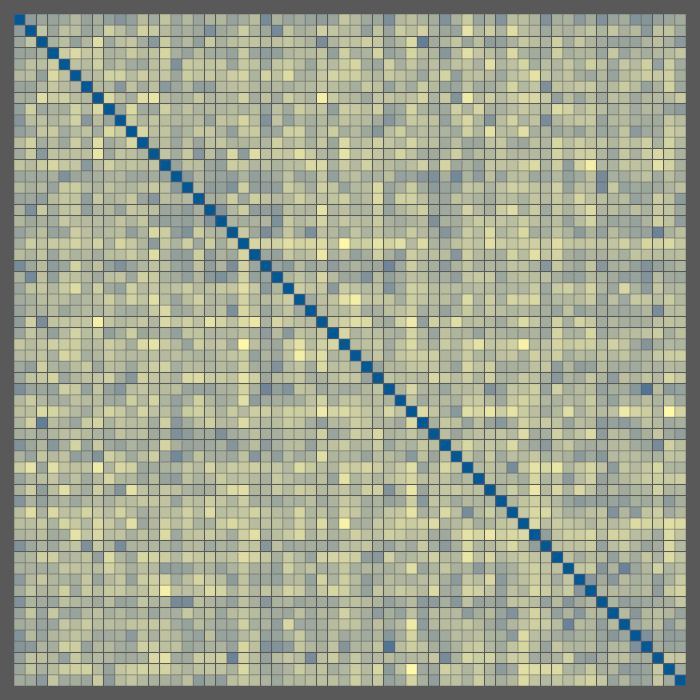

In [5]:
rng = np.random.default_rng(3)
n = 60
# Simulate word-frequency vectors for n documents
df = pd.DataFrame(
    rng.poisson(5, (n, 20)).astype(np.float32),
    columns=[f"word_{i}" for i in range(20)],
)
feature_cols = [f"word_{i}" for i in range(20)]

img = jv.distances(df, columns=feature_cols, metric="cosine",
                   color_ramp=((0.0, 0.1, 0.3), (1.0, 0.95, 0.4)),
                   width=700, height=700)
display(Image.fromarray(img, mode='RGBA'))

## 5 — Structured similarity (block-diagonal)

Items are arranged in three groups; within-group distances are small.

distances: 90×90 (8,100 cells), 750×750, render 5.3ms


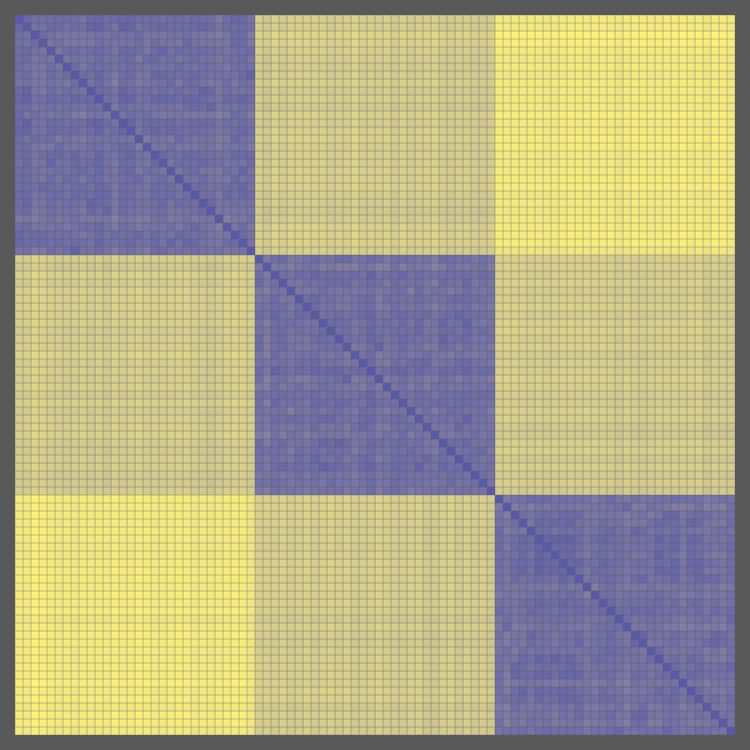

In [6]:
rng = np.random.default_rng(7)
# Three groups of 30 items, 8-dimensional features
groups = [
    rng.normal([0]*8, 0.5, (30, 8)),  # group A — near origin
    rng.normal([5]*8, 0.5, (30, 8)),  # group B — far from A
    rng.normal([10,0,10,0,10,0,10,0], 0.5, (30, 8)),  # group C
]
emb_structured = np.vstack(groups).astype(np.float32)

img = jv.distances(emb_structured, metric="euclidean", width=750, height=750)
display(Image.fromarray(img, mode='RGBA'))